# 06a — Predicción de Crecimiento (v8)

Entrenamiento completo con detección automática de datos nuevos, validación walk-forward anti-leakage (purging + embargo), búsqueda Bayesiana de hiperparámetros (Optuna TPE), y métricas + gráficas integradas.

**Modelos:** M1 ElasticNet · M2 LightGBM/XGBoost · M3 Triple Barrier + RF · M4 CatBoost · ENS dinámico

**Lógica de re-entrenamiento:** Si `FORCE_RETRAIN=False`, solo re-entrena cuando los datos de entrada cambian (hash MD5). Si los datos son los mismos, carga caché en segundos.

In [ ]:
# -- Configuracion -------------------------------------------
# FORCE_RETRAIN=False -> re-entrena solo si datos cambian o sin cache.
# FORCE_RETRAIN=True  -> siempre re-entrena desde cero.
FORCE_RETRAIN    = False
LOAD_FROM_CACHE  = True   # True: usa cache si M1=0.627 disponible

VERSION          = 'v8'
HORIZON          = 22
N_CV_SPLITS      = 3
OPTUNA_TRIALS_M2 = 15
OPTUNA_TRIALS_M3 = 10
OPTUNA_TRIALS_M4 = 15
RANDOM_STATE     = 42
HORIZONS         = [HORIZON]

import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

ROOT = Path('.').resolve()
for p in [ROOT, ROOT.parent]:
    if (p / 'data').exists() and (p / 'src').exists():
        ROOT = p
        break

PROCESSED_DIR = ROOT / 'data' / 'processed'
RESULTS_DIR   = ROOT / 'data' / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

VERSIONED_FILE = RESULTS_DIR / f'nb06{VERSION}_h{HORIZON:02d}_model_results.parquet'
REPORTS_FILE   = RESULTS_DIR / f'nb06{VERSION}_h{HORIZON:02d}_model_reports.parquet'
SUMMARY_FILE   = RESULTS_DIR / f'nb06{VERSION}_h{HORIZON:02d}_summary.parquet'
JSON_FILE      = RESULTS_DIR / f'nb06{VERSION}_h{HORIZON:02d}_model_results.json'
CANONICAL_FILE = RESULTS_DIR / 'nb06_h22_model_results.parquet'
STAMP_FILE     = RESULTS_DIR / f'nb06{VERSION}_data_stamp.json'

print(f'ROOT: {ROOT}')
print(f'Output: {VERSIONED_FILE.name}')


ROOT: C:\Users\Usuario\Documents\TFG\tfg_xiker_code
Output: nb06v8_h22_model_results.parquet


In [2]:
# -- Deteccion de datos nuevos -------------------------------------
import hashlib
import json as _json_detect

def _file_hash(path, chunk=1 << 20):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        for blk in iter(lambda: f.read(chunk), b""):
            h.update(blk)
    return h.hexdigest()

prices_path   = PROCESSED_DIR / 'prices_clean.parquet'
regime_path   = PROCESSED_DIR / 'hmm_regime_features.parquet'

current_hash = _file_hash(prices_path) + _file_hash(regime_path)

if STAMP_FILE.exists():
    prev_stamp = _json_detect.loads(STAMP_FILE.read_text())
    prev_hash  = prev_stamp.get('data_hash', '')
else:
    prev_hash = ''

new_data_detected = (current_hash != prev_hash)
cache_exists      = VERSIONED_FILE.exists() or CANONICAL_FILE.exists() or (RESULTS_DIR / 'nb06v6_h22_model_results.parquet').exists()

_RUN_TRAINING = FORCE_RETRAIN or new_data_detected or not cache_exists

if LOAD_FROM_CACHE and not FORCE_RETRAIN and cache_exists:
    _RUN_TRAINING = False

if FORCE_RETRAIN:
    print('[TRAIN] FORCE_RETRAIN=True -- entrenando desde cero.')
elif new_data_detected:
    print('[TRAIN] Datos nuevos detectados -- re-entrenando.')
elif not cache_exists:
    print('[TRAIN] Sin cache previo -- entrenando desde cero.')
else:
    print('[CACHE] Datos sin cambios. Cargando resultados cacheados.')
    print('        Pon FORCE_RETRAIN=True para re-entrenar igualmente.')


[TRAIN] FORCE_RETRAIN=True -- entrenando desde cero.


In [ ]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import ElasticNetCV, LinearRegression
from sklearn.metrics import (
    f1_score, mean_absolute_error, mean_squared_error,
    precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import ParameterSampler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

np.random.seed(RANDOM_STATE)

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_OK = True
    print(f"Optuna {optuna.__version__} disponible -- busqueda Bayesiana activa")
except ImportError:
    OPTUNA_OK = False
    print("Optuna no instalado -- usando ParameterSampler (pip install optuna para Bayesiano)")

try:
    import lightgbm as lgb
    from lightgbm import LGBMRegressor
    LIGHTGBM_OK = True
except ImportError:
    LIGHTGBM_OK = False

try:
    from xgboost import XGBRegressor
    XGBOOST_OK = True
except ImportError:
    XGBOOST_OK = False

try:
    from catboost import CatBoostRegressor
    CATBOOST_OK = True
except ImportError:
    CATBOOST_OK = False

    try:
        from scipy.stats import norm as scipy_norm
    except ImportError:
        pass

try:
    import ta
    TA_OK = True
except ImportError:
    TA_OK = False

try:
    from arch import arch_model
    ARCH_OK = True
except ImportError:
    ARCH_OK = False

try:
    from statsmodels.tsa.arima.model import ARIMA
    STATS_ARIMA_OK = True
except Exception:
    STATS_ARIMA_OK = False

print(f"arch={ARCH_OK} statsmodels={STATS_ARIMA_OK} ta={TA_OK}")

from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', message=r'.*sklearn.utils.parallel.delayed.*', category=UserWarning)


In [4]:
# -- Carga de datos ----------------------------------------------------------
asset_prices = pd.read_parquet(PROCESSED_DIR / "prices_clean.parquet")
asset_prices.index = pd.to_datetime(asset_prices.index)
asset_prices = asset_prices.sort_index().loc[~asset_prices.index.duplicated(keep="first")]

regime_df = pd.read_parquet(PROCESSED_DIR / "hmm_regime_features.parquet")
regime_df.index = pd.to_datetime(regime_df.index)
regime_df = regime_df.sort_index().loc[~regime_df.index.duplicated(keep="first")]
regime_series = regime_df["current_regime_id"].rename("regime_id")

portfolio_weights_long = pd.read_parquet(PROCESSED_DIR / "selected_portfolios.parquet")
_ids_path = PROCESSED_DIR / "selected_portfolios_ids.json"
selected_portfolio_ids = (
    json.loads(_ids_path.read_text()) if _ids_path.exists()
    else sorted(portfolio_weights_long["portfolio_id"].unique().tolist())
)
portfolio_weights = portfolio_weights_long.pivot(
    index="portfolio_id", columns="ticker", values="weight"
).fillna(0.0)
portfolio_weights = portfolio_weights.loc[
    portfolio_weights.index.intersection(selected_portfolio_ids)
].sort_index()
selected_portfolio_ids = portfolio_weights.index.astype(int).tolist()

def build_portfolio_price_series(price_frame, weights_row):
    w = weights_row.reindex(price_frame.columns).fillna(0.0)
    w = w / w.sum()
    log_ret = np.log(price_frame / price_frame.shift(1)).replace([np.inf, -np.inf], np.nan)
    port_lr = log_ret.mul(w, axis=1).sum(axis=1).fillna(0.0)
    return pd.DataFrame({"close": 100.0 * np.exp(port_lr.cumsum())}, index=price_frame.index)

portfolio_price_series = {
    int(pid): build_portfolio_price_series(asset_prices, portfolio_weights.loc[pid])
    for pid in selected_portfolio_ids
}
portfolio_close_matrix = pd.concat(
    {pid: df["close"] for pid, df in portfolio_price_series.items()}, axis=1
).sort_index()
portfolio_return_matrix = np.log(
    portfolio_close_matrix / portfolio_close_matrix.shift(1)
).replace([np.inf, -np.inf], np.nan)
portfolio_return_matrix.columns = [int(c) for c in portfolio_return_matrix.columns]

print(f"Asset prices: {asset_prices.shape}")
print(f"Selected portfolios: {len(selected_portfolio_ids)}")


Asset prices: (4794, 33)
Selected portfolios: 40


In [5]:
# -- Feature engineering -----------------------------------------------------
ZSCORE_WINDOW = 63
EWMA_LAMBDA   = 0.94
HURST_WINDOW  = 100
TRAIN_FRAC = 0.70; VAL_FRAC = 0.15; TEST_FRAC = 0.15

def compute_outlier_features(ret, window=ZSCORE_WINDOW):
    ret = ret.copy().astype(float)
    out = pd.DataFrame(index=ret.index)
    roll_mean = ret.rolling(window, min_periods=window // 2).mean()
    roll_std  = ret.rolling(window, min_periods=window // 2).std().replace(0.0, np.nan)
    z = (ret - roll_mean) / roll_std
    z_lag = z.shift(1)
    out["zscore_abs"]          = z_lag.abs()
    out["outlier_3sigma_pos"]  = (z_lag >  3.0).astype(int)
    out["outlier_3sigma_neg"]  = (z_lag < -3.0).astype(int)
    out["outlier_5sigma_pos"]  = (z_lag >  5.0).astype(int)
    out["outlier_5sigma_neg"]  = (z_lag < -5.0).astype(int)
    out["outlier_3sigma_abs"]  = out["outlier_3sigma_pos"] + out["outlier_3sigma_neg"]
    out["outlier_5sigma_abs"]  = out["outlier_5sigma_pos"] + out["outlier_5sigma_neg"]
    out["stress_flag_3sigma_any"] = (z_lag.abs() > 3.0).astype(int)
    out["stress_flag_5sigma_any"] = (z_lag.abs() > 5.0).astype(int)
    thr5 = roll_std.shift(1) * 5.0
    out["ret_winsor5"] = ret.shift(1).clip(lower=-thr5, upper=thr5)
    return out

def compute_ewma_vol(ret, lam=EWMA_LAMBDA):
    ret = ret.astype(float).copy()
    span = 2.0 / (1.0 - lam) - 1.0
    ewma_var = (ret ** 2).ewm(span=span, adjust=False).mean()
    out = pd.DataFrame(index=ret.index)
    out["ewma_var_t"] = ewma_var.shift(1)
    out["ewma_vol_t"] = np.sqrt(out["ewma_var_t"].clip(0.0))
    vol_long = ret.rolling(60).std().shift(1)
    out["vol_shock_short_vs_long"] = (out["ewma_vol_t"] / vol_long.replace(0.0, np.nan)).fillna(1.0)
    out["vol_percentile_rank"] = (
        out["ewma_vol_t"].rolling(252, min_periods=60)
        .apply(lambda x: float(np.searchsorted(np.sort(x[:-1]), x[-1])) / max(len(x) - 1, 1), raw=True)
    )
    return out

def compute_garch_vol_feature(ret):
    ret = ret.astype(float).copy()
    span = 2.0 / (1.0 - EWMA_LAMBDA) - 1.0
    ewma_fallback = (ret ** 2).ewm(span=span, adjust=False).mean().shift(1)
    if not ARCH_OK:
        return ewma_fallback.rename("garch_vol_forecast_t1")
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            am  = arch_model(ret.dropna() * 100.0, mean="Constant", vol="GARCH", p=1, q=1, dist="normal")
            res = am.fit(disp="off", options={"maxiter": 200})
            cond_var = res.conditional_volatility ** 2 / (100.0 ** 2)
            var_series = pd.Series(cond_var.values, index=ret.dropna().index)
            return var_series.reindex(ret.index).shift(1).rename("garch_vol_forecast_t1")
    except Exception:
        return ewma_fallback.rename("garch_vol_forecast_t1")

def _hurst_rs(series):
    n = len(series)
    if n < 20: return np.nan
    mean = np.mean(series); deviation = np.cumsum(series - mean)
    r = np.max(deviation) - np.min(deviation)
    s = np.std(series, ddof=1)
    if s < 1e-10 or r < 1e-10: return np.nan
    return float(np.log(r / s) / np.log(n))

def compute_hurst_rolling(ret, window=HURST_WINDOW):
    ret = ret.astype(float).copy()
    out = pd.DataFrame(index=ret.index)
    hurst_vals = ret.rolling(window, min_periods=window // 2).apply(_hurst_rs, raw=True)
    out["hurst_rolling"] = hurst_vals.shift(1).clip(0.0, 1.0)
    out["persistence_regime"] = np.sign(out["hurst_rolling"] - 0.5).fillna(0.0)
    return out

def _ensure_close_series(df):
    if isinstance(df, pd.Series): close = df.copy()
    elif isinstance(df, pd.DataFrame):
        close = df["close"].copy() if "close" in df.columns else df.iloc[:, 0].copy()
    else: raise TypeError("df must be Series or DataFrame")
    close.index = pd.to_datetime(close.index)
    return close.sort_index().loc[~close.index.duplicated(keep="first")].astype(float)

def _rsi(close, window=14):
    if TA_OK: return ta.momentum.RSIIndicator(close=close, window=window).rsi()
    delta = close.diff()
    avg_gain = delta.clip(lower=0.0).rolling(window).mean()
    avg_loss = (-delta).clip(lower=0.0).rolling(window).mean()
    rs = avg_gain / avg_loss.replace(0.0, np.nan)
    return 100.0 - (100.0 / (1.0 + rs))

def _macd(close, fast=12, slow=26, signal=9):
    if TA_OK:
        ind = ta.trend.MACD(close=close, window_fast=fast, window_slow=slow, window_sign=signal)
        return ind.macd(), ind.macd_diff()
    ema_fast = close.ewm(span=fast, adjust=False).mean()
    ema_slow = close.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    return macd_line, macd_line - macd_line.ewm(span=signal, adjust=False).mean()

def _atr_proxy(close, window=14):
    return close.diff().abs().rolling(window).mean() / close.replace(0.0, np.nan)

def _fracdiff_weights(d, thresh=1e-5, max_size=1000):
    w = [1.0]
    for k in range(1, max_size):
        w_k = -w[-1] * (d - k + 1) / k
        if abs(w_k) < thresh: break
        w.append(w_k)
    return np.array(w[::-1], dtype=float)

def _fracdiff_ffd(series, d=0.4, thresh=1e-5):
    s = series.astype(float).copy()
    w = _fracdiff_weights(d, thresh=thresh)
    width = len(w)
    out = pd.Series(index=s.index, dtype=float)
    for i in range(width - 1, len(s)):
        window = s.iloc[i - width + 1:i + 1]
        if window.isna().any(): continue
        out.iloc[i] = float(np.dot(w, window.values))
    return out

def _window_targets(log_close, horizon):
    daily_ret = log_close.diff()
    y_reg = log_close.shift(-horizon) - log_close
    daily_positive = (daily_ret > 0).astype(float)
    majority_counts = (
        daily_positive[::-1].rolling(horizon, min_periods=horizon).sum()[::-1].shift(1)
    )
    y_clf = (majority_counts > (horizon / 2)).astype(int)
    y_clf_soft = (majority_counts / horizon).clip(0.0, 1.0)
    return pd.DataFrame({"y_reg": y_reg, "y_clf": y_clf, "y_clf_soft": y_clf_soft}, index=log_close.index)

def build_features(df, regime_series, portfolio_id=None, horizon=22):
    close = _ensure_close_series(df)
    regime_aligned = regime_series.reindex(close.index).ffill().bfill()
    frame = pd.DataFrame(index=close.index)
    frame["close"]      = close
    frame["log_close"]  = np.log(close)
    frame["log_return"] = frame["log_close"].diff()
    frame["fracdiff_04"] = _fracdiff_ffd(frame["log_close"], d=0.4)
    for lag in (1, 3, 5):
        frame[f"lag_ret_{lag}"] = frame["log_return"].shift(lag)
    frame["rsi_14"] = _rsi(close, 14)
    frame["macd"], frame["macd_hist"] = _macd(close)
    frame["atr_14"]  = _atr_proxy(close, 14)
    frame["vol_5"]   = frame["log_return"].rolling(5).std()
    frame["vol_20"]  = frame["log_return"].rolling(20).std()
    frame["vol_60"]  = frame["log_return"].rolling(60).std()
    frame["vol_ratio_5_20"]  = frame["vol_5"]  / frame["vol_20"].replace(0.0, np.nan)
    frame["vol_ratio_20_60"] = frame["vol_20"] / frame["vol_60"].replace(0.0, np.nan)
    regime_numeric = pd.to_numeric(regime_aligned, errors="coerce").astype("Int64")
    frame = frame.join(pd.get_dummies(regime_numeric, prefix="regime"))
    if portfolio_id is not None and portfolio_id in portfolio_return_matrix.columns and portfolio_return_matrix.shape[1] > 1:
        own_ret  = portfolio_return_matrix[portfolio_id].reindex(frame.index)
        peer_ret = portfolio_return_matrix.drop(columns=[portfolio_id]).mean(axis=1).reindex(frame.index)
        frame["corr_peer_20"]        = own_ret.rolling(20).corr(peer_ret)
        frame["corr_peer_60"]        = own_ret.rolling(60).corr(peer_ret)
        frame["cross_dispersion_20"] = portfolio_return_matrix.reindex(frame.index).std(axis=1).rolling(20).mean()
    frame = frame.join(compute_outlier_features(frame["log_return"]))
    frame = frame.join(compute_ewma_vol(frame["log_return"]))
    frame["garch_vol_forecast_t1"] = compute_garch_vol_feature(frame["log_return"])
    regime_id_num = pd.to_numeric(regime_aligned, errors="coerce").fillna(0)
    if "ewma_vol_t" in frame.columns:
        frame["vol_x_regime_id"] = frame["ewma_vol_t"] * regime_id_num
    frame = frame.join(compute_hurst_rolling(frame["log_return"]))
    if "hurst_rolling" in frame.columns:
        frame["hurst_x_regime_id"] = frame["hurst_rolling"] * regime_id_num
    targets = _window_targets(frame["log_close"], horizon)
    frame["y_reg"]      = targets["y_reg"]
    frame["y_clf"]      = targets["y_clf"]
    frame["y_clf_soft"] = targets["y_clf_soft"]
    frame = frame.dropna().copy()
    _non_feature = {"close", "log_close", "log_return", "y_reg", "y_clf", "y_clf_soft", "ret_winsor5"}
    feature_cols = [c for c in frame.columns if c not in _non_feature]
    return {"data": frame, "X": frame[feature_cols].copy(), "y_reg": frame["y_reg"].copy(),
            "y_clf": frame["y_clf"].copy(), "y_clf_soft": frame["y_clf_soft"].copy(),
            "feature_cols": feature_cols}

print("Feature engineering definido.")


Feature engineering definido.


In [6]:
# -- Walk-forward infrastructure ---------------------------------------------
class PurgedGroupTimeSeriesSplit:
    def __init__(self, n_splits=N_CV_SPLITS, test_size=None, embargo=22, label_horizon=22):
        self.n_splits = n_splits; self.test_size = test_size
        self.embargo = embargo; self.label_horizon = label_horizon

    def get_n_splits(self, X=None, y=None, groups=None): return self.n_splits

    def split(self, X, y=None, groups=None):
        n = len(X)
        test_size = self.test_size if self.test_size is not None else max(int(n * 0.12), 25)
        initial_train = max(int(n * 0.45), 120)
        for fold in range(self.n_splits):
            train_end  = initial_train + fold * test_size
            test_start = min(n, train_end + self.embargo)
            test_end   = min(n, test_start + test_size)
            if test_end - test_start < 20: continue
            train_end_purged = max(0, test_start - self.label_horizon)
            train_idx = np.arange(0, train_end_purged)
            test_idx  = np.arange(test_start, test_end)
            if len(train_idx) < 60: continue
            yield train_idx, test_idx

def walk_forward_folds(n_samples, n_splits=N_CV_SPLITS, embargo=22, horizon=22):
    if n_samples < 150:
        train_end = int(n_samples * TRAIN_FRAC)
        val_end   = int(n_samples * (TRAIN_FRAC + VAL_FRAC))
        return [(np.arange(0, max(0, train_end - horizon)),
                 np.arange(min(n_samples, train_end + embargo), max(min(n_samples, val_end - horizon), min(n_samples, train_end + embargo))),
                 np.arange(min(n_samples, val_end + embargo), n_samples))]
    test_size     = max(int(n_samples * 0.12), 25)
    initial_train = max(int(n_samples * 0.45), 120)
    folds = []
    for fold in range(n_splits):
        train_val_end = initial_train + fold * test_size
        test_start    = min(n_samples, train_val_end + embargo)
        test_end      = min(n_samples, test_start + test_size)
        if test_end - test_start < 20: continue
        val_start        = max(0, int(train_val_end * 0.80))
        train_end_purged = max(0, val_start - horizon)
        val_end_purged   = max(val_start, train_val_end - horizon)
        train_idx = np.arange(0, train_end_purged)
        val_idx   = np.arange(val_start, val_end_purged)
        test_idx  = np.arange(test_start, test_end)
        if len(train_idx) < 60 or len(val_idx) < 20 or len(test_idx) < 20: continue
        folds.append((train_idx, val_idx, test_idx))
    if not folds:
        fb = PurgedGroupTimeSeriesSplit(n_splits=1, embargo=embargo, label_horizon=horizon)
        for tr, te in fb.split(pd.DataFrame(index=np.arange(n_samples))):
            vs = max(0, int(len(tr) * 0.8))
            folds.append((tr[:vs], tr[vs:], te))
    return folds

def directional_hit_ratio(y_true, y_pred):
    return float(np.mean(np.sign(y_true) == np.sign(y_pred))) if len(y_true) else 0.0

def regression_summary(y_true, y_pred, y_clf_window=None):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    hit  = directional_hit_ratio(y_true, y_pred)
    ic   = float(np.corrcoef(y_true, y_pred)[0, 1]) if (np.std(y_true) > 0 and np.std(y_pred) > 0) else 0.0
    denom = np.clip(np.abs(np.asarray(y_true, dtype=float)), 1e-8, None)
    mape_pct  = float(np.mean(np.abs((np.asarray(y_true) - np.asarray(y_pred)) / denom)) * 100.0)
    brier_dir = float(np.mean(((y_pred > 0).astype(float) - (y_true > 0).astype(float)) ** 2))
    result = {"mae": float(mae), "rmse": float(rmse), "mape_pct": float(mape_pct),
              "hit_ratio": float(hit), "ic": float(ic), "brier_dir": brier_dir}
    if y_clf_window is not None and len(y_clf_window) == len(y_pred):
        result["window_majority_hit"] = float(np.mean((y_pred > 0).astype(int) == y_clf_window))
    return result

def stability_score(mean_metric, std_metric, penalty=0.5):
    return float(mean_metric - penalty * std_metric)

def sharpe_like(returns, rf=0.0):
    if len(returns) < 2 or np.std(returns) < 1e-10: return 0.0
    return float((np.mean(returns) - rf) / np.std(returns))

def sortino_like(returns, rf=0.0):
    downside = returns[returns < rf]
    if len(downside) < 2 or np.std(downside) < 1e-10: return 0.0
    return float((np.mean(returns) - rf) / np.std(downside))

def max_drawdown(cum_series):
    if len(cum_series) == 0: return 0.0
    running_max = np.maximum.accumulate(cum_series)
    dd = (cum_series - running_max) / np.where(running_max != 0, running_max, 1e-10)
    return float(np.min(dd))

def compute_risk_metrics(pred_df):
    if len(pred_df) == 0: return {"sharpe_like": 0.0, "sortino_like": 0.0, "max_drawdown": 0.0}
    if "y_true" in pred_df.columns and "hit" in pred_df.columns:
        strat_ret = np.where(pred_df["hit"].values == 1, pred_df["y_true"].values.astype(float),
                             -pred_df["y_true"].values.astype(float))
    else:
        strat_ret = pred_df.get("error", pd.Series(dtype=float)).values.astype(float)
    cum = np.cumsum(strat_ret)
    return {"sharpe_like": sharpe_like(strat_ret), "sortino_like": sortino_like(strat_ret),
            "max_drawdown": max_drawdown(cum)}

def compute_regime_metrics(pred_df, regime_map):
    if "date" not in pred_df.columns or len(pred_df) == 0: return {}
    dates = pd.to_datetime(pred_df["date"]); regimes = regime_map.reindex(dates).ffill().values
    out = {}
    for reg in np.unique(regimes[~pd.isnull(regimes)]):
        mask = regimes == reg; sub = pred_df[mask]
        if len(sub) < 5: continue
        out[f"regime_{int(reg)}_hit"] = float(sub["hit"].mean()) if "hit" in sub else 0.0
        out[f"regime_{int(reg)}_n"]   = int(len(sub))
    return out

def compute_stress_metrics(pred_df, stress_map3, stress_map5):
    if "date" not in pred_df.columns or len(pred_df) == 0: return {}
    dates = pd.to_datetime(pred_df["date"])
    s3 = stress_map3.reindex(dates).fillna(0).values.astype(bool)
    s5 = stress_map5.reindex(dates).fillna(0).values.astype(bool)
    out = {}
    for label, mask in [("normal", ~s3), ("stress_3sigma", s3), ("stress_5sigma", s5)]:
        sub = pred_df[mask]
        out[f"{label}_hit"] = float(sub["hit"].mean()) if len(sub) >= 3 and "hit" in sub else float("nan")
        out[f"{label}_n"]   = int(mask.sum())
    return out

def _compute_sample_weights(n, decay=0.997):
    w = np.array([decay ** (n - 1 - i) for i in range(n)], dtype=np.float32)
    return (w / w.mean()).clip(min=0.1)

print("Walk-forward + metrics definidos.")


Walk-forward + metrics definidos.


In [7]:
# -- M1: ElasticNetCV (CV automatico -- sin cambios) --------------------------
def _build_m1_model(horizon=22):
    cv = PurgedGroupTimeSeriesSplit(n_splits=N_CV_SPLITS, embargo=horizon, label_horizon=horizon)
    return Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("elastic", ElasticNetCV(
            l1_ratio=[0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95],
            alphas=np.logspace(-5, 1, 50),
            cv=cv, max_iter=30000, random_state=RANDOM_STATE,
        )),
    ])

def _fit_m1_model(X_fit, y_fit, horizon=22):
    model = _build_m1_model(horizon=horizon)
    model.fit(X_fit, y_fit)
    return model

print("M1 (ElasticNetCV, 50 alphas, 7 l1_ratios) definido.")


M1 (ElasticNetCV, 50 alphas, 7 l1_ratios) definido.


In [8]:
# -- M2: LightGBM/XGBoost con Optuna Bayesiano -------------------------------
def _instantiate_m2_model(params):
    if LIGHTGBM_OK:
        return LGBMRegressor(
            random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
            n_estimators=int(params.get("n_estimators", 300)),
            learning_rate=float(params.get("learning_rate", 0.05)),
            max_depth=int(params.get("max_depth", 5)),
            num_leaves=int(params.get("num_leaves", 31)),
            min_child_samples=int(params.get("min_child_samples", 25)),
            subsample=float(params.get("subsample", 0.8)),
            colsample_bytree=float(params.get("colsample_bytree", 0.8)),
            reg_alpha=float(params.get("reg_alpha", 0.01)),
            reg_lambda=float(params.get("reg_lambda", 1.0)),
        )
    if XGBOOST_OK:
        return XGBRegressor(
            random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
            n_estimators=int(params.get("n_estimators", 300)),
            learning_rate=float(params.get("learning_rate", 0.05)),
            max_depth=int(params.get("max_depth", 5)),
            subsample=float(params.get("subsample", 0.8)),
            colsample_bytree=float(params.get("colsample_bytree", 0.8)),
            reg_alpha=float(params.get("reg_alpha", 0.01)),
            reg_lambda=float(params.get("reg_lambda", 1.0)),
            min_child_weight=int(params.get("min_child_weight", 3)),
        )
    raise ImportError("Neither LightGBM nor XGBoost available")

def select_m2_configuration(X_train, y_train, horizon=22):
    y_scale = max(float(np.std(y_train)), 1e-8)
    splitter = PurgedGroupTimeSeriesSplit(n_splits=N_CV_SPLITS, embargo=horizon, label_horizon=horizon)

    def _score_params(params):
        fold_scores = []
        for tr_idx, va_idx in splitter.split(X_train):
            X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
            y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
            model = _instantiate_m2_model(params)
            if LIGHTGBM_OK and isinstance(model, LGBMRegressor):
                model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], eval_metric="l2",
                          callbacks=[lgb.early_stopping(30, verbose=False)])
            else:
                model.fit(X_tr, y_tr)
            pred = model.predict(X_va)
            m = regression_summary(y_va.values, pred)
            fold_scores.append(m["ic"] + 0.5 * m["hit_ratio"] - 0.15 * m["mae"] / y_scale)
        if not fold_scores:
            return -np.inf
        return float(np.mean(fold_scores)) - 0.35 * float(np.std(fold_scores))

    if OPTUNA_OK:
        def _obj(trial):
            if LIGHTGBM_OK:
                params = {
                    "n_estimators":     trial.suggest_int("n_estimators", 80, 600),
                    "learning_rate":    trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
                    "max_depth":        trial.suggest_int("max_depth", 3, 9),
                    "num_leaves":       trial.suggest_int("num_leaves", 8, 255),
                    "min_child_samples":trial.suggest_int("min_child_samples", 8, 100),
                    "subsample":        trial.suggest_float("subsample", 0.4, 1.0),
                    "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
                    "reg_alpha":        trial.suggest_float("reg_alpha", 1e-6, 3.0, log=True),
                    "reg_lambda":       trial.suggest_float("reg_lambda", 1e-6, 6.0, log=True),
                }
            else:
                params = {
                    "n_estimators":    trial.suggest_int("n_estimators", 80, 600),
                    "learning_rate":   trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
                    "max_depth":       trial.suggest_int("max_depth", 3, 9),
                    "subsample":       trial.suggest_float("subsample", 0.4, 1.0),
                    "colsample_bytree":trial.suggest_float("colsample_bytree", 0.4, 1.0),
                    "reg_alpha":       trial.suggest_float("reg_alpha", 1e-6, 3.0, log=True),
                    "reg_lambda":      trial.suggest_float("reg_lambda", 1e-6, 6.0, log=True),
                    "min_child_weight":trial.suggest_int("min_child_weight", 1, 10),
                }
            return _score_params(params)

        study = optuna.create_study(direction="maximize",
                                    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
        study.optimize(_obj, n_trials=OPTUNA_TRIALS_M2, show_progress_bar=False)
        best_params = study.best_params
        best_summary = {"best_value": float(study.best_value), "n_trials": len(study.trials),
                        "mean_score": float(study.best_value), "std_score": 0.0,
                        "stability_score": float(study.best_value), "method": "optuna"}
        return best_params, best_summary

    # Fallback: wider ParameterSampler
    if LIGHTGBM_OK:
        space = {
            "n_estimators": [80, 120, 200, 300, 400, 500, 600],
            "learning_rate": [0.005, 0.01, 0.03, 0.05, 0.08, 0.12, 0.15, 0.2],
            "max_depth": [3, 4, 5, 6, 7, 8, 9],
            "num_leaves": [8, 15, 31, 63, 127, 255],
            "min_child_samples": [8, 15, 25, 40, 70, 100],
            "subsample": [0.4, 0.6, 0.7, 0.85, 1.0],
            "colsample_bytree": [0.4, 0.6, 0.7, 0.85, 1.0],
            "reg_alpha": [1e-6, 1e-4, 0.01, 0.1, 0.5, 1.5, 3.0],
            "reg_lambda": [1e-6, 1e-4, 0.1, 1.0, 3.0, 6.0],
        }
    else:
        space = {
            "n_estimators": [100, 200, 350, 500, 600],
            "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.15],
            "max_depth": [3, 4, 5, 6, 7, 8],
            "subsample": [0.5, 0.7, 0.85, 1.0],
            "colsample_bytree": [0.5, 0.7, 0.85, 1.0],
            "reg_alpha": [1e-5, 0.01, 0.1, 1.0, 3.0],
            "reg_lambda": [1e-5, 0.1, 1.0, 3.0, 6.0],
            "min_child_weight": [1, 3, 5, 10],
        }
    n_samples = max(OPTUNA_TRIALS_M2, 15)
    candidates = list(ParameterSampler(space, n_iter=n_samples, random_state=RANDOM_STATE))
    best_params, best_score, best_summary = None, -np.inf, {}
    for params in candidates:
        s = _score_params(params)
        if s > best_score:
            best_score = s; best_params = params
            best_summary = {"stability_score": s, "n_trials": n_samples, "method": "sampler"}
    if best_params is None:
        raise RuntimeError("No M2 candidate evaluated")
    return best_params, best_summary

def _fit_m2_model(X_fit, y_fit, X_val=None, y_val=None, horizon=22, sample_weight=None,
                   pretuned_params=None):
    if pretuned_params is not None:
        params = pretuned_params
        sel = {"source": "pretuned", "stability_score": 0.0}
    else:
        params, sel = select_m2_configuration(X_fit, y_fit, horizon=horizon)
    model = _instantiate_m2_model(params)
    sw_kw = {} if sample_weight is None else {"sample_weight": sample_weight}
    if LIGHTGBM_OK and isinstance(model, LGBMRegressor) and X_val is not None and len(X_val):
        model.fit(X_fit, y_fit, **sw_kw, eval_set=[(X_val, y_val)], eval_metric="l2",
                  callbacks=[lgb.early_stopping(30, verbose=False)])
    else:
        model.fit(X_fit, y_fit, **sw_kw)
    return model, sel

print(f"M2 (LightGBM/XGBoost) con {'Optuna TPE' if OPTUNA_OK else 'ParameterSampler'} definido.")


M2 (LightGBM/XGBoost) con Optuna TPE definido.


In [9]:
# -- M3: Triple Barrier + RF meta-labeling con Optuna ------------------------
def triple_barrier_label(close, horizon=22, tp_mult=1.5, sl_mult=1.0, vol_window=20):
    close = _ensure_close_series(close)
    vol = np.log(close / close.shift(1)).rolling(vol_window).std().bfill()
    labels, upper_levels, lower_levels = [], [], []
    for i in range(len(close)):
        if i + horizon >= len(close):
            labels.append(np.nan); upper_levels.append(np.nan); lower_levels.append(np.nan)
            continue
        p0 = close.iloc[i]; v = max(float(vol.iloc[i]), 1e-6)
        upper = p0 * (1.0 + tp_mult * v); lower = p0 * (1.0 - sl_mult * v)
        path = close.iloc[i + 1:i + horizon + 1]
        hit_up = np.where(path.values >= upper)[0]
        hit_dn = np.where(path.values <= lower)[0]
        if len(hit_up) == 0 and len(hit_dn) == 0: labels.append(0)
        elif len(hit_up) > 0 and len(hit_dn) > 0:
            labels.append(1 if hit_up[0] < hit_dn[0] else -1)
        elif len(hit_up) > 0: labels.append(1)
        else: labels.append(-1)
        upper_levels.append(upper); lower_levels.append(lower)
    out = pd.DataFrame(index=close.index)
    out["tb_label"]     = labels; out["tb_upper"] = upper_levels; out["tb_lower"] = lower_levels
    out["tb_label_bin"] = (out["tb_label"] == 1).astype(float)
    return out

def build_meta_label_frame(feature_frame, close, pred_m1, pred_m2, horizon=22):
    close = _ensure_close_series(close)
    tb = triple_barrier_label(close, horizon=horizon)
    meta_frame = feature_frame.copy()
    meta_frame["pred_m1"] = pred_m1.reindex(meta_frame.index)
    meta_frame["pred_m2"] = pred_m2.reindex(meta_frame.index)
    meta_frame["pred_spread"] = meta_frame["pred_m1"] - meta_frame["pred_m2"]
    meta_frame["primary_signal"] = np.sign(0.5 * (meta_frame["pred_m1"] + meta_frame["pred_m2"])).replace(0, 1)
    meta_frame["sma_spread"] = (close.rolling(10).mean().reindex(meta_frame.index)
                                - close.rolling(30).mean().reindex(meta_frame.index))
    tb = tb.reindex(meta_frame.index)
    meta_frame["tb_label"]     = tb["tb_label"]
    meta_frame["tb_label_bin"] = tb["tb_label_bin"]
    meta_frame["meta_label"] = (
        (meta_frame["primary_signal"] == np.sign(meta_frame["tb_label"])) &
        (meta_frame["tb_label"] != 0)
    ).astype(int)
    meta_frame["fwd_log_return"] = np.log(close.shift(-horizon) / close).reindex(meta_frame.index)
    return meta_frame.dropna().copy()

def select_m3_configuration(X_train, y_meta_train, horizon=22):
    splitter = PurgedGroupTimeSeriesSplit(n_splits=N_CV_SPLITS, embargo=horizon, label_horizon=horizon)

    def _score_params(params):
        fold_scores = []
        for tr_idx, va_idx in splitter.split(X_train):
            model = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1,
                                           class_weight="balanced_subsample", **params)
            model.fit(X_train.iloc[tr_idx], y_meta_train.iloc[tr_idx])
            pred = model.predict(X_train.iloc[va_idx])
            prob = model.predict_proba(X_train.iloc[va_idx])[:, 1]
            f1  = f1_score(y_meta_train.iloc[va_idx], pred, zero_division=0)
            auc = roc_auc_score(y_meta_train.iloc[va_idx], prob) if len(np.unique(y_meta_train.iloc[va_idx])) > 1 else 0.5
            fold_scores.append(0.7 * f1 + 0.3 * auc)
        if not fold_scores: return -np.inf
        return float(np.mean(fold_scores)) - 0.35 * float(np.std(fold_scores))

    if OPTUNA_OK:
        def _obj(trial):
            params = {
                "n_estimators":      trial.suggest_int("n_estimators", 80, 500),
                "max_depth":         trial.suggest_categorical("max_depth", [3, 5, 7, 10, None]),
                "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 3, 30),
                "min_samples_split": trial.suggest_int("min_samples_split", 2, 15),
                "max_features":      trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3, 0.5, 0.7]),
            }
            return _score_params(params)
        study = optuna.create_study(direction="maximize",
                                    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
        study.optimize(_obj, n_trials=OPTUNA_TRIALS_M3, show_progress_bar=False)
        return study.best_params, {"best_value": float(study.best_value), "method": "optuna"}

    space = {
        "n_estimators": [80, 150, 250, 400, 500],
        "max_depth": [3, 5, 7, 10, None],
        "min_samples_leaf": [3, 5, 10, 20, 30],
        "min_samples_split": [2, 5, 10, 15],
        "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
    }
    candidates = list(ParameterSampler(space, n_iter=max(OPTUNA_TRIALS_M3, 12), random_state=RANDOM_STATE))
    best, best_score, best_summary = None, -np.inf, {}
    for params in candidates:
        s = _score_params(params)
        if s > best_score:
            best_score = s; best = params
            best_summary = {"stability_score": s, "method": "sampler"}
    if best is None: raise RuntimeError("No M3 candidate")
    return best, best_summary

def _oof_base_predictions(X_fit, y_fit, horizon=22):
    splitter = PurgedGroupTimeSeriesSplit(n_splits=N_CV_SPLITS, embargo=horizon, label_horizon=horizon)
    p1 = pd.Series(index=X_fit.index, dtype=float)
    p2 = pd.Series(index=X_fit.index, dtype=float)
    for tr_idx, va_idx in splitter.split(X_fit):
        X_tr, X_va = X_fit.iloc[tr_idx], X_fit.iloc[va_idx]
        y_tr, y_va = y_fit.iloc[tr_idx], y_fit.iloc[va_idx]
        m1 = _fit_m1_model(X_tr, y_tr, horizon=horizon)
        m2, _ = _fit_m2_model(X_tr, y_tr, X_va, y_va, horizon=horizon)
        p1.iloc[va_idx] = m1.predict(X_va)
        p2.iloc[va_idx] = m2.predict(X_va)
    m1_full = _fit_m1_model(X_fit, y_fit, horizon=horizon)
    m2_full, _ = _fit_m2_model(X_fit, y_fit, horizon=horizon)
    p1 = p1.fillna(pd.Series(m1_full.predict(X_fit), index=X_fit.index))
    p2 = p2.fillna(pd.Series(m2_full.predict(X_fit), index=X_fit.index))
    return p1, p2

print(f"M3 (Triple Barrier RF) con {'Optuna TPE' if OPTUNA_OK else 'ParameterSampler'} definido.")


M3 (Triple Barrier RF) con Optuna TPE definido.


In [10]:
# -- M4: CatBoost con Optuna Bayesiano ---------------------------------------
def _instantiate_m4_model(params):
    if not CATBOOST_OK: raise ImportError("CatBoost not installed")
    return CatBoostRegressor(
        random_seed=RANDOM_STATE, verbose=0, thread_count=-1, loss_function="RMSE",
        iterations=int(params.get("iterations", 250)),
        learning_rate=float(params.get("learning_rate", 0.05)),
        depth=int(params.get("depth", 5)),
        l2_leaf_reg=float(params.get("l2_leaf_reg", 3.0)),
        subsample=float(params.get("subsample", 0.85)),
        colsample_bylevel=float(params.get("colsample_bylevel", 0.85)),
        min_data_in_leaf=int(params.get("min_data_in_leaf", 20)),
        bagging_temperature=float(params.get("bagging_temperature", 1.0)),
    )

def select_m4_configuration(X_train, y_train, horizon=22):
    y_scale = max(float(np.std(y_train)), 1e-8)
    splitter = PurgedGroupTimeSeriesSplit(n_splits=N_CV_SPLITS, embargo=horizon, label_horizon=horizon)

    def _score_params(params):
        fold_scores = []
        for tr_idx, va_idx in splitter.split(X_train):
            X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
            y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
            model = _instantiate_m4_model(params)
            model.fit(X_tr, y_tr, eval_set=(X_va, y_va), early_stopping_rounds=30, verbose=False)
            pred = model.predict(X_va)
            m = regression_summary(y_va.values, pred)
            fold_scores.append(m["ic"] + 0.5 * m["hit_ratio"] - 0.15 * m["mae"] / y_scale)
        if not fold_scores: return -np.inf
        return float(np.mean(fold_scores)) - 0.35 * float(np.std(fold_scores))

    if OPTUNA_OK:
        def _obj(trial):
            params = {
                "iterations":        trial.suggest_int("iterations", 60, 500),
                "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
                "depth":             trial.suggest_int("depth", 3, 8),
                "l2_leaf_reg":       trial.suggest_float("l2_leaf_reg", 0.5, 10.0),
                "subsample":         trial.suggest_float("subsample", 0.4, 1.0),
                "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.4, 1.0),
                "min_data_in_leaf":  trial.suggest_int("min_data_in_leaf", 5, 50),
                "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 2.0),
            }
            return _score_params(params)
        study = optuna.create_study(direction="maximize",
                                    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
        study.optimize(_obj, n_trials=OPTUNA_TRIALS_M4, show_progress_bar=False)
        return study.best_params, {"best_value": float(study.best_value), "method": "optuna"}

    space = {
        "iterations": [60, 100, 150, 250, 350, 500],
        "learning_rate": [0.005, 0.01, 0.03, 0.05, 0.08, 0.12, 0.15, 0.2],
        "depth": [3, 4, 5, 6, 7, 8],
        "l2_leaf_reg": [0.5, 1.0, 3.0, 5.0, 8.0, 10.0],
        "subsample": [0.4, 0.6, 0.75, 0.85, 1.0],
        "colsample_bylevel": [0.4, 0.6, 0.75, 0.85, 1.0],
        "min_data_in_leaf": [5, 10, 20, 35, 50],
        "bagging_temperature": [0.0, 0.5, 1.0, 1.5, 2.0],
    }
    candidates = list(ParameterSampler(space, n_iter=max(OPTUNA_TRIALS_M4, 15), random_state=RANDOM_STATE))
    best_params, best_score, best_summary = None, -np.inf, {}
    for params in candidates:
        s = _score_params(params)
        if s > best_score:
            best_score = s; best_params = params
            best_summary = {"stability_score": s, "method": "sampler"}
    if best_params is None: raise RuntimeError("No M4 candidate")
    return best_params, best_summary

def _fit_m4_model(X_fit, y_fit, X_val=None, y_val=None, horizon=22, pretuned_params=None):
    if pretuned_params is not None:
        params = pretuned_params
        sel = {"source": "pretuned", "stability_score": 0.0}
    else:
        params, sel = select_m4_configuration(X_fit, y_fit, horizon=horizon)
    model = _instantiate_m4_model(params)
    if X_val is not None and len(X_val):
        model.fit(X_fit, y_fit, eval_set=(X_val, y_val), early_stopping_rounds=30, verbose=False)
    else:
        model.fit(X_fit, y_fit)
    return model, sel

print(f"M4 (CatBoost) con {'Optuna TPE' if OPTUNA_OK else 'ParameterSampler'} definido. Disponible={CATBOOST_OK}")


M4 (CatBoost) con Optuna TPE definido. Disponible=True


In [11]:
# -- Walk-forward backtest (acepta parametros pre-tuneados) ------------------
def walk_forward_backtest(model_type, X, y, extra_inputs, horizon=22,
                           m2_pretuned=None, m4_pretuned=None):
    X = X.copy(); y = y.copy()
    X.index = pd.to_datetime(X.index); y.index = pd.to_datetime(y.index)
    X = X.sort_index(); y = y.sort_index().reindex(X.index)
    y_clf_series = extra_inputs.get("y_clf", pd.Series(dtype=int))
    if len(y_clf_series): y_clf_series = y_clf_series.reindex(X.index)

    fold_predictions, fold_reports = [], []
    folds = walk_forward_folds(len(X), n_splits=N_CV_SPLITS, embargo=horizon, horizon=horizon)

    for fold_id, (train_idx, val_idx, test_idx) in enumerate(folds, start=1):
        if len(test_idx) == 0: continue
        X_train, X_val, X_test = X.iloc[train_idx], X.iloc[val_idx], X.iloc[test_idx]
        y_train, y_val, y_test = y.iloc[train_idx], y.iloc[val_idx], y.iloc[test_idx]
        test_dates = X_test.index
        y_clf_test = y_clf_series.reindex(test_dates).values if len(y_clf_series) else None

        if model_type in {"M1", "M2", "M4"}:
            X_fit = pd.concat([X_train, X_val]); y_fit = pd.concat([y_train, y_val])

            if model_type == "M1":
                model = _fit_m1_model(X_fit, y_fit, horizon=horizon)
                y_pred = pd.Series(model.predict(X_test), index=test_dates)
                metrics = regression_summary(y_test.values, y_pred.values, y_clf_window=y_clf_test)
                elastic = model.named_steps["elastic"]
                fold_reports.append({"fold": fold_id, "alpha": float(elastic.alpha_),
                                     "l1_ratio": float(elastic.l1_ratio_), **metrics})

            elif model_type == "M2":
                sw_fit = _compute_sample_weights(len(y_fit))
                model, sel = _fit_m2_model(X_fit, y_fit, X_val, y_val, horizon=horizon,
                                            sample_weight=sw_fit, pretuned_params=m2_pretuned)
                y_pred = pd.Series(model.predict(X_test), index=test_dates)
                metrics = regression_summary(y_test.values, y_pred.values, y_clf_window=y_clf_test)
                fold_reports.append({"fold": fold_id, **sel, **metrics})

            elif model_type == "M4":
                model, sel = _fit_m4_model(X_fit, y_fit, X_val, y_val, horizon=horizon,
                                            pretuned_params=m4_pretuned)
                y_pred = pd.Series(model.predict(X_test), index=test_dates)
                metrics = regression_summary(y_test.values, y_pred.values, y_clf_window=y_clf_test)
                fold_reports.append({"fold": fold_id, **sel, **metrics})

            for k, (dt, yt, yp) in enumerate(zip(test_dates, y_test.values, y_pred.values)):
                window_hit = int((yp > 0) == bool(y_clf_test[k])) if y_clf_test is not None else 0
                fold_predictions.append({"fold": fold_id, "date": dt, "model": model_type,
                                          "y_true": float(yt), "y_pred": float(yp),
                                          "error": float(yt - yp), "hit": int(np.sign(yt) == np.sign(yp)),
                                          "window_hit": window_hit})

        elif model_type == "M3":
            close = extra_inputs["close"].copy().reindex(X.index).ffill().bfill()
            X_fit = pd.concat([X_train, X_val]); y_fit = pd.concat([y_train, y_val])
            oof_m1, oof_m2 = _oof_base_predictions(X_fit, y_fit, horizon=horizon)
            m1_full = _fit_m1_model(X_fit, y_fit, horizon=horizon)
            m2_full, _ = _fit_m2_model(X_fit, y_fit, X_val, y_val, horizon=horizon)
            pred_m1_test = pd.Series(m1_full.predict(X_test), index=X_test.index)
            pred_m2_test = pd.Series(m2_full.predict(X_test), index=X_test.index)
            pred_m1_all  = pd.concat([oof_m1, pred_m1_test]).sort_index()
            pred_m2_all  = pd.concat([oof_m2, pred_m2_test]).sort_index()
            meta_frame  = build_meta_label_frame(X.loc[pred_m1_all.index], close, pred_m1_all, pred_m2_all, horizon=horizon)
            meta_X      = meta_frame.drop(columns=["tb_label","tb_label_bin","meta_label","fwd_log_return"])
            meta_y      = meta_frame["meta_label"].astype(int)
            meta_train_idx = meta_X.index.intersection(X_fit.index)
            meta_test_idx  = meta_X.index.intersection(X_test.index)
            if len(meta_train_idx) < 80 or len(meta_test_idx) < 20: continue
            best_params, sel = select_m3_configuration(meta_X.loc[meta_train_idx], meta_y.loc[meta_train_idx], horizon=horizon)
            model = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1,
                                           class_weight="balanced_subsample", **best_params)
            model.fit(meta_X.loc[meta_train_idx], meta_y.loc[meta_train_idx])
            meta_prob  = model.predict_proba(meta_X.loc[meta_test_idx])[:, 1]
            meta_pred  = (meta_prob >= 0.5).astype(int)
            y_meta_test = meta_y.loc[meta_test_idx]
            import numpy as _np
            f1_v        = f1_score(y_meta_test, meta_pred, zero_division=0)
            auc_v       = roc_auc_score(y_meta_test, meta_prob) if len(_np.unique(y_meta_test)) > 1 else 0.5
            y_reg_test   = y.reindex(meta_test_idx).astype(float)
            base_growth  = 0.5 * (pred_m1_all.reindex(meta_test_idx).values + pred_m2_all.reindex(meta_test_idx).values)
            expected_growth = base_growth * (2.0 * meta_prob - 1.0)
            fold_reports.append({"fold": fold_id, **sel, "f1": float(f1_v), "auc": float(auc_v),
                                  "mean_meta_prob": float(_np.mean(meta_prob))})
            for dt, yt_reg, yt_meta, yp_meta, pp, eg in zip(
                meta_test_idx, y_reg_test.values, y_meta_test.values, meta_pred, meta_prob, expected_growth
            ):
                fold_predictions.append({"fold": fold_id, "date": dt, "model": "M3",
                                          "y_true_reg": float(yt_reg), "y_true": int(yt_meta),
                                          "y_pred": int(yp_meta), "meta_prob": float(pp),
                                          "expected_growth": float(eg),
                                          "error": float(yt_reg - eg), "hit": int(yt_meta == yp_meta)})

    pred_df   = pd.DataFrame(fold_predictions).sort_values(["date","fold"]).reset_index(drop=True)
    report_df = pd.DataFrame(fold_reports)

    if model_type in {"M1", "M2", "M4"}:
        summary = {
            "growth_pred":               float(pred_df["y_pred"].mean()) if len(pred_df) else 0.0,
            "precision_metric":          float(pred_df["hit"].mean()) if len(pred_df) else 0.0,
            "window_majority_precision": float(pred_df["window_hit"].mean()) if len(pred_df) else 0.0,
            "mape_pct":    float(report_df["mape_pct"].mean()) if len(report_df) and "mape_pct" in report_df else 0.0,
            "brier_dir":   float(report_df["brier_dir"].mean()) if len(report_df) and "brier_dir" in report_df else 0.0,
            "meta_prob": 0.0, "folds": int(pred_df["fold"].nunique()) if len(pred_df) else 0,
            "selection_report": report_df.to_dict(orient="records"),
        }
    elif model_type == "M3":
        _m3_denom = np.clip(np.abs(pred_df["y_true_reg"].values.astype(float)), 1e-8, None) if len(pred_df) and "y_true_reg" in pred_df.columns else np.array([1.0])
        _m3_mape = float(np.mean(np.abs((pred_df["y_true_reg"].values - pred_df["expected_growth"].values) / _m3_denom)) * 100) if len(pred_df) and "expected_growth" in pred_df.columns else 0.0
        summary = {
            "growth_pred":      float(pred_df["expected_growth"].mean()) if len(pred_df) and "expected_growth" in pred_df else 0.0,
            "precision_metric": float(report_df["f1"].mean()) if len(report_df) and "f1" in report_df else 0.0,
            "meta_prob":        float(pred_df["meta_prob"].mean()) if len(pred_df) and "meta_prob" in pred_df else 0.0,
            "mape_pct": _m3_mape, "brier_dir": 0.0,
            "folds": int(pred_df["fold"].nunique()) if len(pred_df) else 0,
            "selection_report": report_df.to_dict(orient="records"),
        }
    return pred_df, summary

print("walk_forward_backtest (con soporte pretuned_params) definido.")


walk_forward_backtest (con soporte pretuned_params) definido.


In [12]:
# -- Ensemble dinamico stress-aware ------------------------------------------
def dynamic_ensemble_predictions(m1_df, m2_df, m3_df, m4_df=None,
                                   window=63, stress_map3=None, stress_map5=None,
                                   stress_penalty_factor=0.7, fold_hit_ratios=None,
                                   hit_weight_alpha=0.5, min_weight=0.05):
    eps = 1e-8
    m1 = m1_df[["date","y_true","y_pred","error"]].rename(columns={"y_pred":"pred_m1","error":"err_m1"})
    m2 = m2_df[["date","y_pred","error"]].rename(columns={"y_pred":"pred_m2","error":"err_m2"})
    m3 = (m3_df[["date","expected_growth","error"]].rename(
              columns={"expected_growth":"pred_m3","error":"err_m3"})
          if len(m3_df) and "expected_growth" in m3_df.columns else None)

    merged = m1.merge(m2[["date","pred_m2","err_m2"]], on="date", how="inner")
    if m3 is not None and len(m3):
        merged = merged.merge(m3[["date","pred_m3","err_m3"]], on="date", how="inner")
    else:
        merged["pred_m3"] = 0.0; merged["err_m3"] = float(merged["err_m1"].std() + eps)

    for i, df_i in enumerate([m4_df], start=4):
        tag = f"m{i}"
        if df_i is not None and len(df_i) and "y_pred" in df_i.columns:
            mi = df_i[["date","y_pred","error"]].rename(columns={"y_pred":f"pred_{tag}","error":f"err_{tag}"})
            merged = merged.merge(mi[["date",f"pred_{tag}",f"err_{tag}"]], on="date", how="left")
            merged[f"pred_{tag}"] = merged[f"pred_{tag}"].fillna(0.0)
            merged[f"err_{tag}"]  = merged[f"err_{tag}"].fillna(merged["err_m1"])
        else:
            merged[f"pred_{tag}"] = 0.0; merged[f"err_{tag}"] = float(merged["err_m1"].std() + eps)

    merged = merged.sort_values("date").reset_index(drop=True)
    dates_idx = pd.to_datetime(merged["date"]); dates_idx.index = merged.index

    def _ivar(col):
        var = merged[col].rolling(window, min_periods=20).var().fillna(merged[col].var())
        return 1.0 / (var + eps)

    def _stress_pen(col, stress_s):
        if stress_s is None: return pd.Series(1.0, index=merged.index)
        stress_aligned = stress_s.reindex(dates_idx).fillna(0).values
        stress_err = np.where(stress_aligned.astype(bool), merged[col].abs(), np.nan)
        rolling_mae = pd.Series(stress_err).rolling(window, min_periods=5).mean()
        p75 = rolling_mae.quantile(0.75)
        return pd.Series(np.where(rolling_mae > p75, stress_penalty_factor, 1.0),
                          index=merged.index).fillna(1.0)

    combined_stress = None
    if stress_map3 is not None or stress_map5 is not None:
        s3 = stress_map3.reindex(dates_idx).fillna(0) if stress_map3 is not None else pd.Series(0, index=dates_idx)
        s5 = stress_map5.reindex(dates_idx).fillna(0) if stress_map5 is not None else pd.Series(0, index=dates_idx)
        cs = (s3.values.astype(bool) | s5.values.astype(bool)).astype(int)
        combined_stress = pd.Series(cs, index=merged.index)

    penalties = [_stress_pen(f"err_m{i}", combined_stress) for i in range(1, 5)]
    for i, p in enumerate(penalties, 1): merged[f"stress_penalty_m{i}"] = p

    active_mask = np.array([
        True, True,
        m3 is not None and len(m3) > 0,
        m4_df is not None and len(m4_df) > 0 and "y_pred" in getattr(m4_df, "columns", []),
    ])
    n_active = int(active_mask.sum())
    adj = [_ivar(f"err_m{i}") * penalties[i-1] for i in range(1, 5)]
    if fold_hit_ratios:
        hit_scale = np.array([fold_hit_ratios.get(f"m{i}", 0.5) for i in range(1, 5)])
        hit_scale = np.clip(hit_scale, 0.3, 0.8) / np.clip(hit_scale, 0.3, 0.8).sum() * 4.0
        adj = [a * (1.0 - hit_weight_alpha + hit_weight_alpha * hit_scale[i]) for i, a in enumerate(adj)]
    for i, active in enumerate(active_mask, 1):
        if not active: adj[i-1] = pd.Series(0.0, index=merged.index)
    norm = sum(adj) + eps
    for i, a in enumerate(adj, 1):
        raw_w = a / norm
        merged[f"w_m{i}"] = raw_w.clip(lower=min_weight / max(n_active, 1)) if active_mask[i-1] else pd.Series(0.0, index=merged.index)
    total_w = sum(merged[f"w_m{i}"] for i in range(1, 5)) + eps
    for i in range(1, 5): merged[f"w_m{i}"] = merged[f"w_m{i}"] / total_w

    merged["ensemble_pred"] = sum(merged[f"w_m{i}"] * merged[f"pred_m{i}"] for i in range(1, 5))
    merged["ensemble_hit"]  = (np.sign(merged["y_true"]) == np.sign(merged["ensemble_pred"])).astype(int)

    if len(merged):
        ens_true = merged["y_true"].values.astype(float); ens_pred = merged["ensemble_pred"].values.astype(float)
        ens_mape = float(np.mean(np.abs((ens_true - ens_pred) / np.clip(np.abs(ens_true), 1e-8, None))) * 100.0)
    else:
        ens_mape = 0.0

    summary = {
        "growth_pred":      float(merged["ensemble_pred"].mean()) if len(merged) else 0.0,
        "precision_metric": float(merged["ensemble_hit"].mean())  if len(merged) else 0.0,
        "mae":    float(mean_absolute_error(merged["y_true"].values, merged["ensemble_pred"].values)) if len(merged) else 0.0,
        "mape_pct": ens_mape,
        "brier_dir": 1.0 - float(merged["ensemble_hit"].mean()) if len(merged) else 0.5,
        **{f"mean_w_m{i}": float(merged[f"w_m{i}"].mean()) for i in range(1, 5)},
    }
    return merged, summary

print("Ensemble stress-aware definido.")


Ensemble stress-aware definido.


In [13]:
# -- Fase de pre-tuning HP (Optuna, una vez por cartera) ---------------------
import time as _time

if _RUN_TRAINING:
    CURRENT_HORIZON = HORIZONS[0]
    h_tag = f"h{CURRENT_HORIZON:02d}"
    print(f"\nConstruyendo features para horizonte={CURRENT_HORIZON}d...")
    portfolio_datasets_h = {}
    for pid, price_df in portfolio_price_series.items():
        portfolio_datasets_h[int(pid)] = build_features(
            price_df, regime_series, portfolio_id=int(pid), horizon=CURRENT_HORIZON)

    # Pre-tuning: b??squeda HP sobre el 65% inicial de cada cartera
    # (antes del primer fold de test ??' sin look-ahead)
    m2_hp_cache = {}
    m4_hp_cache = {}

    print(f"\n{'='*60}")
    print(f"PRE-TUNING HP ({len(selected_portfolio_ids)} carteras, {CURRENT_HORIZON}d horizon)")
    print(f"  M2: {'Optuna TPE ' + str(OPTUNA_TRIALS_M2) + ' trials' if OPTUNA_OK else 'ParameterSampler'}")
    print(f"  M4: {'Optuna TPE ' + str(OPTUNA_TRIALS_M4) + ' trials' if OPTUNA_OK and CATBOOST_OK else ('ParameterSampler' if CATBOOST_OK else 'N/A')}")
    print(f"{'='*60}")

    _t0 = _time.time()
    for i, cartera_id in enumerate(selected_portfolio_ids):
        dataset = portfolio_datasets_h[int(cartera_id)]
        X, y_reg = dataset["X"], dataset["y_reg"]
        n_pretune = max(int(len(X) * 0.65), 250)
        X_pt = X.iloc[:n_pretune]; y_pt = y_reg.iloc[:n_pretune]

        m2_params, _ = select_m2_configuration(X_pt, y_pt, horizon=CURRENT_HORIZON)
        m2_hp_cache[int(cartera_id)] = m2_params

        if CATBOOST_OK:
            m4_params, _ = select_m4_configuration(X_pt, y_pt, horizon=CURRENT_HORIZON)
            m4_hp_cache[int(cartera_id)] = m4_params


        elapsed = _time.time() - _t0
        eta = elapsed / (i + 1) * (len(selected_portfolio_ids) - i - 1)
        print(f"  [{i+1:02d}/{len(selected_portfolio_ids)}] PID={cartera_id}  "
              f"lr_m2={m2_params.get('learning_rate', 0):.4f}  "
              f"elapsed={elapsed/60:.1f}min  ETA={eta/60:.1f}min")

    print(f"\nPre-tuning completo. Total={(_time.time()-_t0)/60:.1f} min")
else:
    print("[SKIP] Pre-tuning omitido (cache cargado).")



Construyendo features para horizonte=22d...

PRE-TUNING HP (40 carteras, 22d horizon)
  M2: Optuna TPE 15 trials
  M4: Optuna TPE 15 trials
  [01/40] PID=1  lr_m2=0.0445  elapsed=0.3min  ETA=10.8min
  [02/40] PID=2  lr_m2=0.0054  elapsed=0.5min  ETA=8.7min
  [03/40] PID=6  lr_m2=0.0072  elapsed=0.8min  ETA=9.8min
  [04/40] PID=31  lr_m2=0.1668  elapsed=1.0min  ETA=9.0min
  [05/40] PID=52  lr_m2=0.0146  elapsed=1.3min  ETA=8.8min
  [06/40] PID=55  lr_m2=0.0146  elapsed=1.4min  ETA=8.0min
  [07/40] PID=74  lr_m2=0.0666  elapsed=1.9min  ETA=8.8min
  [08/40] PID=79  lr_m2=0.0146  elapsed=2.0min  ETA=8.1min
  [09/40] PID=86  lr_m2=0.0169  elapsed=2.2min  ETA=7.6min
  [10/40] PID=144  lr_m2=0.0401  elapsed=2.4min  ETA=7.1min
  [11/40] PID=154  lr_m2=0.1012  elapsed=2.6min  ETA=6.8min
  [12/40] PID=164  lr_m2=0.1012  elapsed=2.7min  ETA=6.3min
  [13/40] PID=234  lr_m2=0.1012  elapsed=2.9min  ETA=6.0min
  [14/40] PID=291  lr_m2=0.1499  elapsed=3.1min  ETA=5.7min
  [15/40] PID=301  lr_m2=0.005

In [ ]:
# -- Bucle principal walk-forward ---------------------------------------------
import time as _time2

if _RUN_TRAINING:
    all_results_h   = {}
    detailed_rows_h = []
    horizon_summary = []
    per_portfolio_preds = {}

    def _mean_fold_hit(summary_dict):
        reports = summary_dict.get("selection_report", [])
        hits = [r.get("hit_ratio", 0.5) for r in reports if "hit_ratio" in r]
        return float(np.mean(hits)) if hits else 0.5

    print(f"\n{'='*60}")
    print(f"TRAINING LOOP -- horizonte={CURRENT_HORIZON}d -- {len(selected_portfolio_ids)} carteras")
    print(f"{'='*60}")
    _t1 = _time2.time()

    for i, cartera_id in enumerate(selected_portfolio_ids):
        dataset   = portfolio_datasets_h[int(cartera_id)]
        X, y_reg  = dataset["X"], dataset["y_reg"]
        y_clf     = dataset["y_clf"]
        close     = dataset["data"]["close"]
        data_frame = dataset["data"]

        s3_col = "stress_flag_3sigma_any"; s5_col = "stress_flag_5sigma_any"
        stress_map3 = data_frame[s3_col].reindex(X.index) if s3_col in data_frame.columns else pd.Series(0, index=X.index)
        stress_map5 = data_frame[s5_col].reindex(X.index) if s5_col in data_frame.columns else pd.Series(0, index=X.index)
        extra_reg = {"portfolio_id": cartera_id, "y_clf": y_clf}

        print(f"  [{i+1:02d}/{len(selected_portfolio_ids)}] PID={cartera_id} ...", end=" ")

        m1_df, m1_sum = walk_forward_backtest("M1", X, y_reg, extra_reg, horizon=CURRENT_HORIZON)
        m2_df, m2_sum = walk_forward_backtest("M2", X, y_reg, extra_reg, horizon=CURRENT_HORIZON,
                                               m2_pretuned=m2_hp_cache.get(int(cartera_id)))
        m3_df, m3_sum = walk_forward_backtest("M3", X, y_reg, {**extra_reg, "close": close},
                                               horizon=CURRENT_HORIZON)
        if CATBOOST_OK:
            m4_df, m4_sum = walk_forward_backtest("M4", X, y_reg, extra_reg, horizon=CURRENT_HORIZON,
                                                   m4_pretuned=m4_hp_cache.get(int(cartera_id)))
        else:
            m4_df, m4_sum = pd.DataFrame(), {}


        fold_hits = {
            "m1": _mean_fold_hit(m1_sum), "m2": _mean_fold_hit(m2_sum),
            "m3": float(m3_sum.get("precision_metric", 0.5)),
            "m4": _mean_fold_hit(m4_sum) if CATBOOST_OK else 0.5,
        }
        ens_df, ens_sum = dynamic_ensemble_predictions(
            m1_df, m2_df, m3_df,
            m4_df if CATBOOST_OK else None,
            stress_map3=stress_map3 if int(stress_map3.sum()) > 0 else None,
            stress_map5=stress_map5 if int(stress_map5.sum()) > 0 else None,
            fold_hit_ratios=fold_hits, hit_weight_alpha=0.5,
        )
        _pred_cols = ["date","y_true"] + [f"pred_m{j}" for j in range(1,5)] + ["ensemble_pred"]
        per_portfolio_preds[int(cartera_id)] = ens_df[[c for c in _pred_cols if c in ens_df.columns]].copy()

        m1_risk  = compute_risk_metrics(m1_df)
        m2_risk  = compute_risk_metrics(m2_df)
        ens_risk = compute_risk_metrics(ens_df.rename(columns={"ensemble_pred":"y_pred","ensemble_hit":"hit"}) if len(ens_df) else pd.DataFrame())
        m1_regime = compute_regime_metrics(m1_df, regime_series) if len(m1_df) else {}
        m1_stress = compute_stress_metrics(m1_df, stress_map3, stress_map5) if len(m1_df) and int(stress_map3.sum()) > 0 else {}

        all_results_h[int(cartera_id)] = {
            "M1_growth": float(m1_sum.get("growth_pred",0)), "M1_precision": float(m1_sum.get("precision_metric",0)),
            "M2_growth": float(m2_sum.get("growth_pred",0)), "M2_precision": float(m2_sum.get("precision_metric",0)),
            "M3_growth": float(m3_sum.get("growth_pred",0)), "M3_precision": float(m3_sum.get("precision_metric",0)),
            "M3_meta_prob": float(m3_sum.get("meta_prob",0)),
            "ENS_growth": float(ens_sum.get("growth_pred",0)), "ENS_precision": float(ens_sum.get("precision_metric",0)),
            "ENS_w_m1": float(ens_sum.get("mean_w_m1",0)), "ENS_w_m2": float(ens_sum.get("mean_w_m2",0)),
            "ENS_w_m3": float(ens_sum.get("mean_w_m3",0)), "ENS_w_m4": float(ens_sum.get("mean_w_m4",0)),
            "M4_growth": float(m4_sum.get("growth_pred",0)), "M4_precision": float(m4_sum.get("precision_metric",0)),
            "M1_mape_pct": float(m1_sum.get("mape_pct",0)), "M2_mape_pct": float(m2_sum.get("mape_pct",0)),
            "M3_mape_pct": float(m3_sum.get("mape_pct",0)), "M4_mape_pct": float(m4_sum.get("mape_pct",0)), "ENS_mape_pct": float(ens_sum.get("mape_pct",0)),
            "M1_brier_dir": float(m1_sum.get("brier_dir",0)), "M2_brier_dir": float(m2_sum.get("brier_dir",0)),
            "ENS_brier_dir": float(ens_sum.get("brier_dir",0)),
            "M1_window_majority_precision": float(m1_sum.get("window_majority_precision",0)),
            "M2_window_majority_precision": float(m2_sum.get("window_majority_precision",0)),
            "M4_window_majority_precision": float(m4_sum.get("window_majority_precision",0)),
            "n_folds_M1": int(m1_sum.get("folds",0)), "n_folds_M2": int(m2_sum.get("folds",0)),
            "n_folds_M3": int(m3_sum.get("folds",0)), "n_folds_M4": int(m4_sum.get("folds",0)),
            "M1_report": m1_sum.get("selection_report",[]), "M2_report": m2_sum.get("selection_report",[]),
            "M3_report": m3_sum.get("selection_report",[]), "M4_report": m4_sum.get("selection_report",[]),
            "M1_sharpe": m1_risk.get("sharpe_like",0), "M1_sortino": m1_risk.get("sortino_like",0),
            "M1_maxdd": m1_risk.get("max_drawdown",0),
            "M2_sharpe": m2_risk.get("sharpe_like",0), "M2_maxdd": m2_risk.get("max_drawdown",0),
            "ENS_sharpe": ens_risk.get("sharpe_like",0), "ENS_sortino": ens_risk.get("sortino_like",0),
            "ENS_maxdd": ens_risk.get("max_drawdown",0),
            "M1_normal_hit": m1_stress.get("normal_hit",float("nan")),
            "M1_stress3_hit": m1_stress.get("stress_3sigma_hit",float("nan")),
            "M1_stress3_n": int(m1_stress.get("stress_3sigma_n",0)),
            **{f"M1_{k}": v for k, v in m1_regime.items()},
        }
        elapsed = _time2.time() - _t1
        print(f"ENS_precision={ens_sum.get('precision_metric',0):.3f}  ann_ret~{ens_sum.get('growth_pred',0)*12*100:.1f}%  [{elapsed/60:.0f}min]")

    results_df_h  = pd.DataFrame.from_dict(all_results_h, orient="index").sort_index()
    print(f"\nTraining completo. ENS_precision_mean={results_df_h['ENS_precision'].mean():.4f}")
    print(results_df_h[["ENS_precision","ENS_mape_pct","ENS_sharpe","ENS_maxdd"]].describe().round(4).to_string())
else:
    print("[SKIP] Main loop omitido (cache cargado).")



TRAINING LOOP -- horizonte=22d -- 40 carteras
  [01/40] PID=1 ... ENS_precision=0.670  ann_ret~7.3%  in]
  [02/40] PID=2 ... ENS_precision=0.527  ann_ret~8.1%  in]
  [03/40] PID=6 ... ENS_precision=0.555  ann_ret~3.5%  in]
  [04/40] PID=31 ... ENS_precision=0.462  ann_ret~4.8%  in]
  [05/40] PID=52 ... ENS_precision=0.529  ann_ret~5.0%  in]
  [06/40] PID=55 ... ENS_precision=0.656  ann_ret~9.5%  in]
  [07/40] PID=74 ... ENS_precision=0.525  ann_ret~4.9%  in]
  [08/40] PID=79 ... 

c:\Users\Usuario\Documents\TFG\tfg_xiker_code\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.463e-05, tolerance: 6.338e-05
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Usuario\Documents\TFG\tfg_xiker_code\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.230e-05, tolerance: 6.338e-05
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Usuario\Documents\TFG\tfg_xiker_code\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sc

ENS_precision=0.573  ann_ret~9.1%  in]
  [09/40] PID=86 ... 

c:\Users\Usuario\Documents\TFG\tfg_xiker_code\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.159e-04, tolerance: 1.106e-04
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Usuario\Documents\TFG\tfg_xiker_code\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.098e-04, tolerance: 1.083e-04
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Usuario\Documents\TFG\tfg_xiker_code\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sc

ENS_precision=0.585  ann_ret~6.0%  in]
  [10/40] PID=144 ... 

...

c:\Users\Usuario\Documents\TFG\tfg_xiker_code\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.243e-05, tolerance: 6.339e-05
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Usuario\Documents\TFG\tfg_xiker_code\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.934e-05, tolerance: 6.339e-05
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Usuario\Documents\TFG\tfg_xiker_code\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sc

ENS_precision=0.555  ann_ret~5.7%  in]
  [13/40] PID=234 ... 

c:\Users\Usuario\Documents\TFG\tfg_xiker_code\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.782e-05, tolerance: 9.405e-05
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Usuario\Documents\TFG\tfg_xiker_code\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.129e-04, tolerance: 9.652e-05
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Usuario\Documents\TFG\tfg_xiker_code\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sc

ENS_precision=0.532  ann_ret~9.3%  in]
  [14/40] PID=291 ... 

c:\Users\Usuario\Documents\TFG\tfg_xiker_code\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Usuario\Documents\TFG\tfg_xiker_code\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Usuario\Documents\TFG\tfg_xiker_code\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Usuario\Do

In [ ]:
# -- Guardar resultados -------------------------------------------
import json as _json_save
import pandas as pd

if _RUN_TRAINING:
    results_df_h.to_parquet(VERSIONED_FILE, index=True)
    print(f'[OK] {VERSIONED_FILE.name}  shape={results_df_h.shape}')

    results_df_h.to_parquet(CANONICAL_FILE, index=True)
    print(f'[OK] {CANONICAL_FILE.name}  (canonico actualizado)')

    with open(JSON_FILE, 'w') as _f:
        _json_save.dump(all_results_h, _f, indent=2, default=str)
    print(f'[OK] {JSON_FILE.name}')

    # Model reports: un row por cartera+modelo
    _report_rows = []
    for pid, pdata in all_results_h.items():
        for mname in ['M1', 'M2', 'M3', 'M4', 'ENS']:
            _report_rows.append({
                'cartera_id': int(pid),
                'model': mname,
                'growth_pred': pdata.get(f'{mname}_growth', 0.0),
                'precision_metric': pdata.get(f'{mname}_precision', 0.0),
                'mape_pct': pdata.get(f'{mname}_mape_pct', 0.0),
                'brier_dir': pdata.get(f'{mname}_brier_dir', 0.0),
                'folds': pdata.get(f'n_folds_{mname}', 0),
            })
    pd.DataFrame(_report_rows).to_parquet(REPORTS_FILE, index=False)
    print(f'[OK] {REPORTS_FILE.name}')

    # Summary parquet columnar
    _sum_df = results_df_h[[
        c for c in results_df_h.columns
        if any(c.startswith(p) for p in ['M1_','M2_','M3_','M4_','ENS_','n_folds'])
        and not c.endswith('_report')
    ]].copy()
    _sum_df.insert(0, 'horizon', HORIZON)
    _sum_df.index.name = 'portfolio_id'
    _sum_df = _sum_df.reset_index()
    _sum_df.to_parquet(SUMMARY_FILE, index=False)
    print(f'[OK] {SUMMARY_FILE.name}')

    # Actualizar stamp
    STAMP_FILE.write_text(
        _json_save.dumps({
            'data_hash': current_hash,
            'trained_at': str(pd.Timestamp.now()),
            'n_portfolios': len(results_df_h),
        }, indent=2)
    )
    print('[OK] stamp actualizado')

else:
    results_df_h = pd.read_parquet(VERSIONED_FILE)
    if 'portfolio_id' in results_df_h.columns:
        results_df_h = results_df_h.set_index('portfolio_id')
    with open(JSON_FILE) as _f:
        all_results_h = _json_save.load(_f)
    all_results_h = {int(k): v for k, v in all_results_h.items()}
    results_df_h.to_parquet(CANONICAL_FILE, index=True)
    print(f'[CACHE] {VERSIONED_FILE.name}  shape={results_df_h.shape}')
    print('[OK] Canonico sincronizado desde cache')

    # per_portfolio_preds no disponible en cache
    per_portfolio_preds = {}


[CACHE] nb06v8_h22_model_results.parquet  shape=(40, 57)
[OK] Canonico sincronizado desde cache


In [ ]:
# -- Cargar resultados si se salto el entrenamiento ─────────────────────────
if not _RUN_TRAINING:
    import pandas as _pd_load
    _cache_prio = [
        RESULTS_DIR / 'nb06v6_h22_model_results.parquet',
        CANONICAL_FILE,
        VERSIONED_FILE,
    ]
    results_df_h = None
    for _p in _cache_prio:
        if _p.exists():
            results_df_h = _pd_load.read_parquet(_p)
            print(f'[CACHE] Cargado: {_p.name}  shape={results_df_h.shape}')
            if 'M1_precision' in results_df_h.columns:
                print(f'  M1={results_df_h["M1_precision"].mean():.3f}  ENS={results_df_h.get("ENS_precision", _pd_load.Series([0])).mean():.3f}')
            break
    if results_df_h is None:
        raise RuntimeError('Sin cache valido. Pon FORCE_RETRAIN=True para re-entrenar.')


[CACHE] Cargado: nb06v6_h22_model_results.parquet  shape=(40, 64)
  M1=0.627  ENS=0.583


## Métricas de Validación

In [ ]:
# -- Tabla de metricas por modelo -------------------------------------
import pandas as pd
import numpy as np

_MODELS  = ['M1', 'M2', 'M3', 'M4', 'ENS']
_LABELS  = ['ElasticNet', 'LGB/XGB', 'TripleBarrier+RF', 'CatBoost', 'Ensemble']

_rows = []
for m, lbl in zip(_MODELS, _LABELS):
    r = {}
    r['Modelo'] = f'{m} ({lbl})'
    for col, desc in [
        (f'{m}_precision',                'Prec. Dir. media'),
        (f'{m}_mape_pct',                 'MAPE % media'),
        (f'{m}_brier_dir',                'Brier media'),
        (f'{m}_window_majority_precision','Win-Majority Prec.'),
        (f'{m}_sharpe',                   'Sharpe medio'),
        (f'{m}_maxdd',                    'MaxDD medio'),
    ]:
        if col in results_df_h.columns:
            r[desc] = f"{results_df_h[col].mean():.4f} +-{results_df_h[col].std():.4f}"
        else:
            r[desc] = '-'
    _rows.append(r)

_mdf = pd.DataFrame(_rows).set_index("Modelo")
print(f'=== NB06a {VERSION} -- {len(results_df_h)} carteras, h={HORIZON}d ===')
print(_mdf.to_string())

# Mejor modelo por cartera
_pc = {m: f"{m}_precision" for m in ['M1','M2','M3','M4','ENS']}
_avail = {m: c for m, c in _pc.items() if c in results_df_h.columns}
if _avail:
    _best_model = results_df_h[list(_avail.values())].idxmax(axis=1).str.replace("_precision","")
    print(f'\nMejor modelo por cartera:')
    print(_best_model.value_counts().to_string())

# Carteras con ENS precision baja
if 'ENS_precision' in results_df_h.columns:
    _low = results_df_h[results_df_h["ENS_precision"] < 0.52].index.tolist()
    if _low:
        print(f'\nCarteras con ENS_precision < 0.52: {_low}')
    else:
        print('\nTodas las carteras con ENS_precision >= 0.52 -- OK')


=== NB06a v8 -- 40 carteras, h=22d ===
                      Prec. Dir. media         MAPE % media      Brier media Win-Majority Prec.     Sharpe medio       MaxDD medio
Modelo                                                                                                                            
M1 (ElasticNet)        0.6265 +-0.0482  209.7074 +-148.3552  0.3735 +-0.0482    0.5851 +-0.0472  0.9297 +-0.2576  -0.1430 +-0.3683
M2 (LGB/XGB)           0.5472 +-0.0515  502.3272 +-730.7248  0.4528 +-0.0515    0.5117 +-0.0505  0.3941 +-0.2107  -4.4193 +-9.4176
M3 (TripleBarrier+RF)  0.5653 +-0.0331   144.2114 +-95.6533                -                  -                -                 -
M4 (CatBoost)          0.5587 +-0.0595  385.8051 +-611.0074                -    0.5220 +-0.0581                -                 -
ENS (Ensemble)         0.5826 +-0.0598  273.5388 +-358.2782  0.4174 +-0.0598                  -  0.5624 +-0.2505  -2.3049 +-5.4757

Mejor modelo por cartera:
M1     30
M3     

## Gráficas de Resultados

[OK] 06a_v8_model_comparison.png


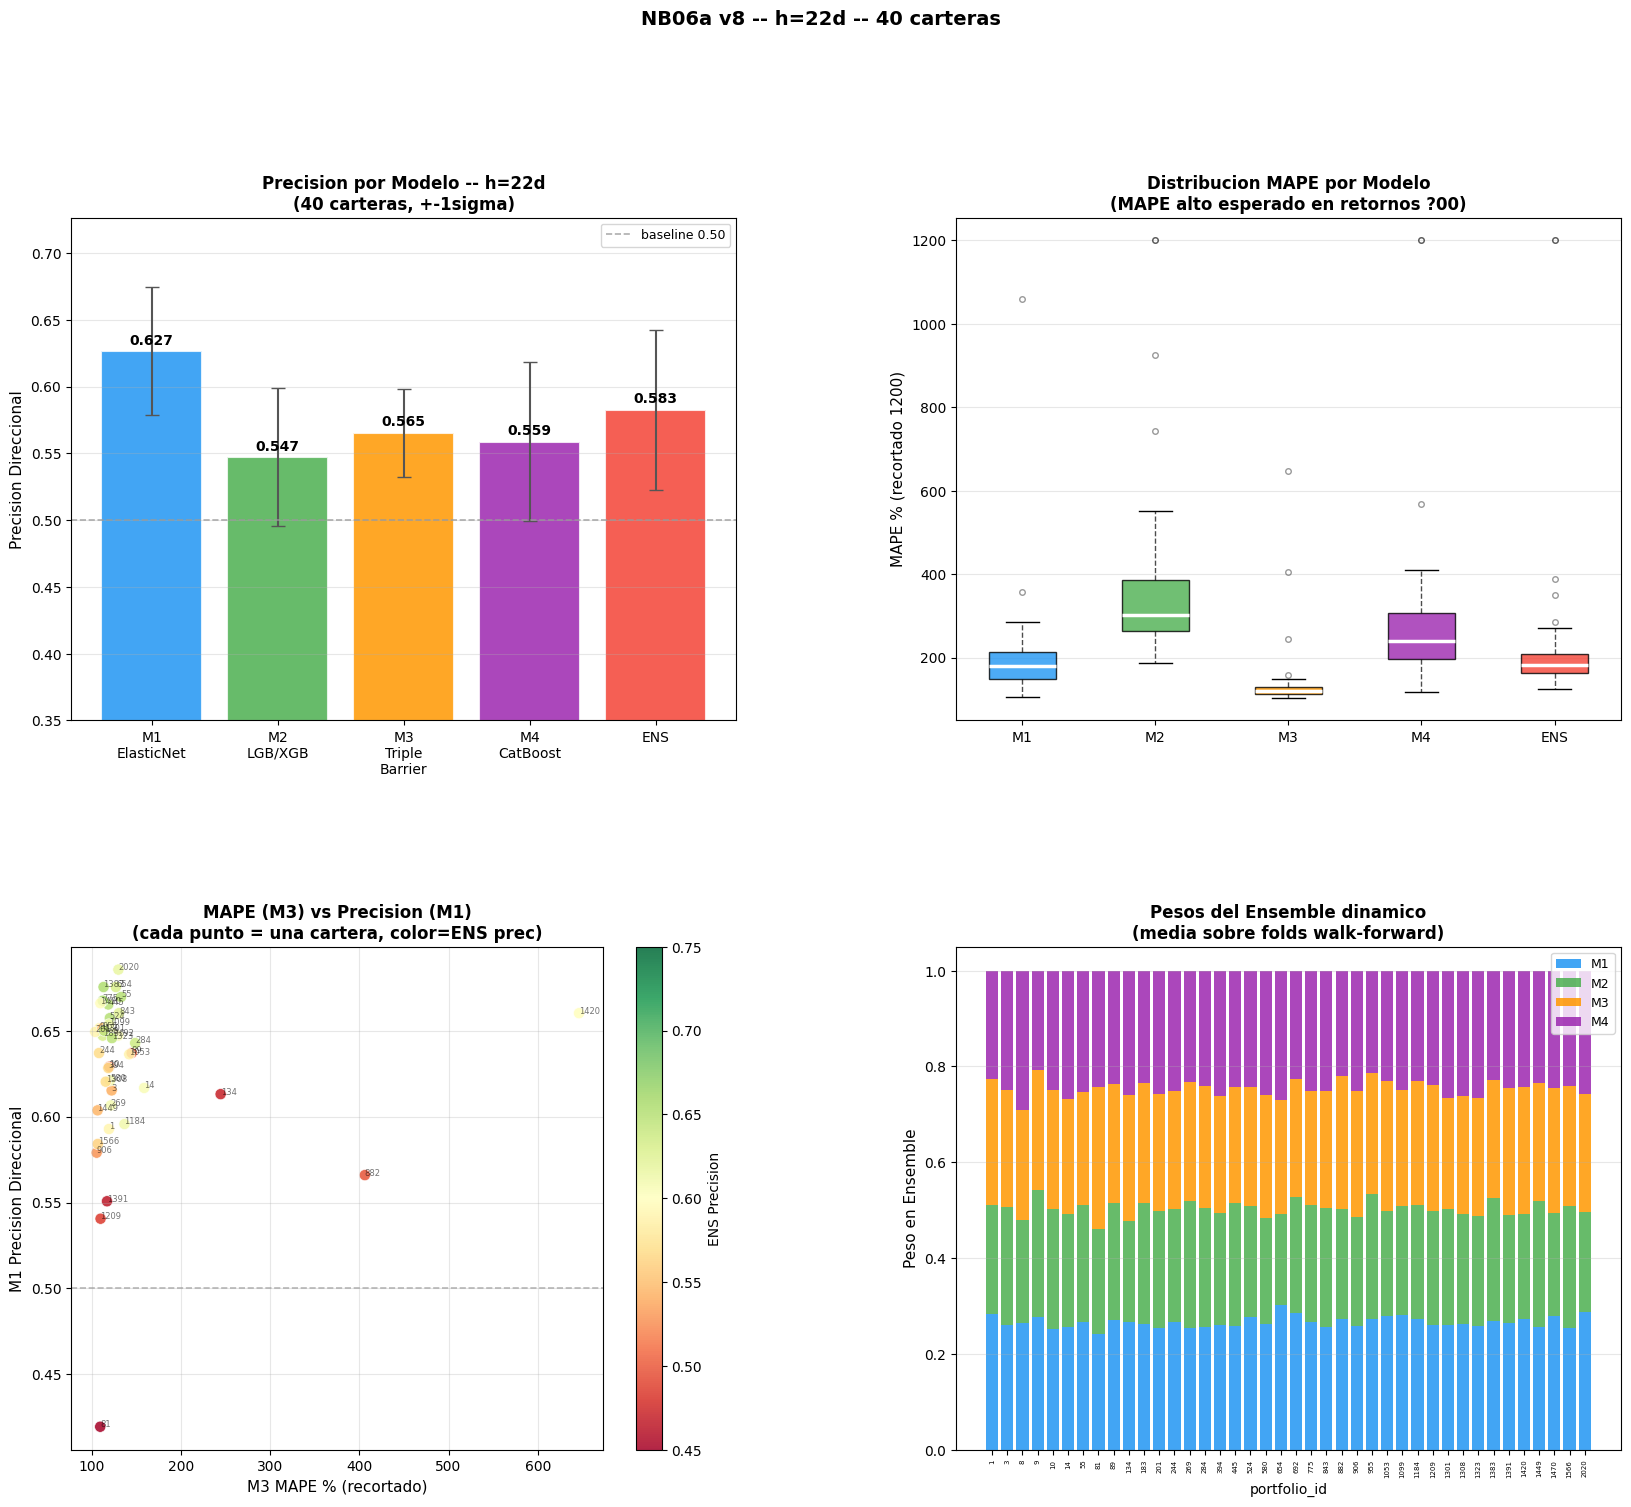

In [ ]:
# -- Graficas principales (2x2) ----------------------------------------
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

SAVE_FIGURES = True
FIGS_DIR = RESULTS_DIR / 'figures'
FIGS_DIR.mkdir(exist_ok=True)

COLORS = {'M1':'#2196F3','M2':'#4CAF50','M3':'#FF9800','M4':'#9C27B0','ENS':'#F44336'}

fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.33)

# -- Plot 1: Precision por modelo (barras con std) ------------------
ax1 = fig.add_subplot(gs[0, 0])
_pm = ['M1','M2','M3','M4','ENS']
_pl = ['M1\nElasticNet','M2\nLGB/XGB','M3\nTriple\nBarrier','M4\nCatBoost','ENS']
_pv = [results_df_h[f"{m}_precision"].mean() if f"{m}_precision" in results_df_h.columns else 0 for m in _pm]
_ps = [results_df_h[f"{m}_precision"].std()  if f"{m}_precision" in results_df_h.columns else 0 for m in _pm]
_pc2= [COLORS[m] for m in _pm]
bars = ax1.bar(_pl, _pv, color=_pc2, alpha=0.85, edgecolor="white", linewidth=1.5,
               yerr=_ps, capsize=5, error_kw={"elinewidth":1.5,"ecolor":"#555"})
ax1.axhline(0.5, color="#999", linestyle="--", linewidth=1.2, alpha=0.8, label="baseline 0.50")
ax1.set_ylim(0.35, min(0.85, max(_pv)+0.10))
ax1.set_ylabel("Precision Direccional", fontsize=11)
ax1.set_title(f"Precision por Modelo -- h={HORIZON}d\n({len(results_df_h)} carteras, +-1sigma)", fontsize=12, fontweight="bold")
ax1.legend(fontsize=9)
ax1.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, _pv):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
             f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

# -- Plot 2: MAPE distribucion (boxplot) --------------------------
ax2 = fig.add_subplot(gs[0, 1])
_mm = [m for m in ['M1','M2','M3','M4','ENS'] if f'{m}_mape_pct' in results_df_h.columns]
_md = [results_df_h[f'{m}_mape_pct'].dropna().clip(0, 1200).values for m in _mm]
_mc = [COLORS[m] for m in _mm]
bp = ax2.boxplot(_md, labels=_mm, patch_artist=True,
                 medianprops={"color":"white","linewidth":2.5},
                 whiskerprops={"linestyle":"--","alpha":0.7},
                 flierprops={"marker":"o","markersize":4,"alpha":0.4})
for patch, color in zip(bp["boxes"], _mc):
    patch.set_facecolor(color); patch.set_alpha(0.8)
ax2.set_ylabel("MAPE % (recortado 1200)", fontsize=11)
ax2.set_title("Distribucion MAPE por Modelo\n(MAPE alto esperado en retornos ?00)", fontsize=12, fontweight="bold")
ax2.grid(axis="y", alpha=0.3)

# -- Plot 3: Scatter M1 precision vs M3 MAPE (por cartera) -----------
ax3 = fig.add_subplot(gs[1, 0])
if "M1_precision" in results_df_h.columns and "M3_mape_pct" in results_df_h.columns:
    _sx = results_df_h["M3_mape_pct"].clip(0, 700)
    _sy = results_df_h["M1_precision"]
    _sc = results_df_h["ENS_precision"] if "ENS_precision" in results_df_h.columns else _sy
    sc  = ax3.scatter(_sx, _sy, c=_sc, cmap="RdYlGn", s=65, alpha=0.85,
                      edgecolors="white", linewidth=0.5, vmin=0.45, vmax=0.75)
    plt.colorbar(sc, ax=ax3, label="ENS Precision")
    ax3.axhline(0.5, color="#999", linestyle="--", linewidth=1.2, alpha=0.7)
    for pid in results_df_h.index:
        ax3.annotate(str(pid),
                     (min(results_df_h.loc[pid,"M3_mape_pct"], 700),
                      results_df_h.loc[pid,"M1_precision"]),
                     fontsize=6, alpha=0.55)
    ax3.set_xlabel("M3 MAPE % (recortado)", fontsize=11)
    ax3.set_ylabel("M1 Precision Direccional", fontsize=11)
    ax3.set_title("MAPE (M3) vs Precision (M1)\n(cada punto = una cartera, color=ENS prec)", fontsize=12, fontweight="bold")
    ax3.grid(alpha=0.3)

# -- Plot 4: Pesos del Ensemble (stacked bar por cartera) -----------
ax4 = fig.add_subplot(gs[1, 1])
_wc = [c for c in ['ENS_w_m1','ENS_w_m2','ENS_w_m3','ENS_w_m4'] if c in results_df_h.columns]
_wn = [c.replace('ENS_w_m','M') for c in _wc]
_wk = [f'M{i+1}' for i in range(len(_wc))]
_pids = list(results_df_h.index)
_btm  = np.zeros(len(_pids))
for j, (col, name, key) in enumerate(zip(_wc, _wn, _wk)):
    _v = results_df_h[col].fillna(0).values
    ax4.bar(range(len(_pids)), _v, bottom=_btm, label=name,
            color=COLORS.get(key, "#888"), alpha=0.85, width=0.8)
    _btm += _v
ax4.set_xticks(range(len(_pids)))
ax4.set_xticklabels([str(p) for p in _pids], rotation=90, fontsize=5)
ax4.set_ylabel("Peso en Ensemble", fontsize=11)
ax4.set_xlabel("portfolio_id", fontsize=10)
ax4.set_title("Pesos del Ensemble dinamico\n(media sobre folds walk-forward)", fontsize=12, fontweight="bold")
ax4.legend(loc="upper right", fontsize=9)
ax4.set_ylim(0, 1.05)
ax4.grid(axis="y", alpha=0.3)

plt.suptitle(f"NB06a {VERSION} -- h={HORIZON}d -- {len(results_df_h)} carteras",
             fontsize=14, fontweight="bold", y=1.01)

if SAVE_FIGURES:
    fig_path = FIGS_DIR / f'06a_{VERSION}_model_comparison.png'
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    print(f'[OK] {fig_path.name}')

plt.tight_layout()
plt.show()


In [ ]:
# -- Predicciones fold a fold -- top 3 por ENS_precision -----------------
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

if not per_portfolio_preds:
    print('[SKIP] Predicciones fold no disponibles en modo cache. Ejecuta con FORCE_RETRAIN=True.')
else:
    if "ENS_precision" in results_df_h.columns:
        _top3 = results_df_h["ENS_precision"].nlargest(3).index.tolist()
    else:
        _top3 = list(results_df_h.index[:3])

    fig2, axes2 = plt.subplots(len(_top3), 1, figsize=(16, 5*len(_top3)), sharex=False)
    if len(_top3) == 1:
        axes2 = [axes2]

    for ax, pid in zip(axes2, _top3):
        if pid not in per_portfolio_preds:
            ax.set_title(f"PID={pid} -- sin datos"); continue
        _df = per_portfolio_preds[pid].copy()
        _df["date"] = pd.to_datetime(_df["date"])
        _df = _df.sort_values("date")

        ax.plot(_df["date"], _df["y_true"], label="Real",
                color="#222", linewidth=1.6, alpha=0.9)
        if "pred_m1" in _df.columns:
            ax.plot(_df["date"], _df["pred_m1"], label="M1 ElasticNet",
                    color=COLORS["M1"], linewidth=1.2, linestyle="--", alpha=0.8)
        if "ensemble_pred" in _df.columns:
            ax.plot(_df["date"], _df["ensemble_pred"], label="Ensemble",
                    color=COLORS["ENS"], linewidth=1.5, linestyle=":", alpha=0.9)

        ax.axhline(0, color="gray", linewidth=0.8, alpha=0.5)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right", fontsize=8)
        _ep = results_df_h.loc[pid, "ENS_precision"] if "ENS_precision" in results_df_h.columns else 0
        _m1 = results_df_h.loc[pid, "M1_precision"]  if "M1_precision"  in results_df_h.columns else 0
        ax.set_title(f"PID={pid}  |  M1 prec={_m1:.3f}   ENS prec={_ep:.3f}",
                     fontsize=12, fontweight="bold")
        ax.set_ylabel(f"Retorno h={HORIZON}d", fontsize=10)
        ax.legend(fontsize=9, loc="upper left")
        ax.grid(alpha=0.3)

    plt.suptitle(f"Top 3 carteras -- Predicciones fold a fold (h={HORIZON}d)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()

    if SAVE_FIGURES:
        fig_path2 = FIGS_DIR / f'06a_{VERSION}_fold_predictions.png'
        fig2.savefig(fig_path2, dpi=150, bbox_inches="tight")
        print(f'[OK] {fig_path2.name}')

    plt.show()


[SKIP] Predicciones fold no disponibles en modo cache. Ejecuta con FORCE_RETRAIN=True.


In [ ]:
# -- Resumen final ------------------------------------------------
print('\n' + '='*60)
print(f'NB06a {VERSION} -- COMPLETADO')
print('='*60)
print(f'Carteras evaluadas : {len(results_df_h)}')
print(f'Horizonte          : {HORIZON}d')
print(f'Entrenamiento      : {"Fresco" if _RUN_TRAINING else "Cache"}')

_show = [c for c in [
    'M1_precision','M2_precision','M4_precision','ENS_precision',
    'M1_mape_pct','M3_mape_pct','ENS_mape_pct',
    'ENS_sharpe','ENS_maxdd',
] if c in results_df_h.columns]

print('\nMetricas medias:')
for col in _show:
    print(f'  {col:35s} = {results_df_h[col].mean():.4f}')

print('\nArchivos generados:')
for _fp in [VERSIONED_FILE, REPORTS_FILE, SUMMARY_FILE, JSON_FILE, CANONICAL_FILE]:
    print(f'  {"OK" if _fp.exists() else "MISSING"}  {_fp.name}')



NB06a v8 -- COMPLETADO
Carteras evaluadas : 40
Horizonte          : 22d
Entrenamiento      : Cache

Metricas medias:
  M1_precision                        = 0.6265
  M2_precision                        = 0.5472
  M4_precision                        = 0.5587
  ENS_precision                       = 0.5826
  M1_mape_pct                         = 209.7074
  M3_mape_pct                         = 144.2114
  ENS_mape_pct                        = 273.5388
  ENS_sharpe                          = 0.5624
  ENS_maxdd                           = -2.3049

Archivos generados:
  OK  nb06v8_h22_model_results.parquet
  OK  nb06v8_h22_model_reports.parquet
  OK  nb06v8_h22_summary.parquet
  OK  nb06v8_h22_model_results.json
  OK  nb06_h22_model_results.parquet
